In [21]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import simulator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Test pack/unpack: round-trip should give back what we started with
test_positions = np.array([
    [1.0, 0.0, 0.0],   # body 0 at (1, 0, 0)
    [-0.5, 0.866, 0.0], # body 1 at (-0.5, 0.866, 0)
    [-0.5, -0.866, 0.0] # body 2 at (-0.5, -0.866, 0)
])
test_velocities = np.array([
    [0.0, 0.5, 0.0],
    [-0.433, -0.25, 0.0],
    [0.433, -0.25, 0.0]
])

state = simulator.pack(test_positions, test_velocities)
print("Flat state shape:", state.shape)
print("Flat state:", state)

pos_back, vel_back = simulator.unpack(state)
print("\nPositions match:", np.allclose(pos_back, test_positions))
print("Velocities match:", np.allclose(vel_back, test_velocities))

Flat state shape: (18,)
Flat state: [ 1.     0.     0.    -0.5    0.866  0.    -0.5   -0.866  0.     0.
  0.5    0.    -0.433 -0.25   0.     0.433 -0.25   0.   ]

Positions match: True
Velocities match: True


In [23]:
# Sanity check 1: equilateral triangle of equal masses
# By symmetry, all bodies should accelerate toward the centroid (origin)
# with equal magnitudes.

# Place bodies at corners of equilateral triangle, centered at origin
positions = np.array([
    [1.0, 0.0, 0.0],
    [-0.5, np.sqrt(3)/2, 0.0],
    [-0.5, -np.sqrt(3)/2, 0.0]
])
masses = np.array([1.0, 1.0, 1.0])

accelerations = simulator.compute_accelerations(positions, masses)

print("Accelerations:")
print(accelerations)
print()

# Each body should point back toward origin
for i in range(3):
    direction_to_origin = -positions[i] / np.linalg.norm(positions[i])
    accel_direction = accelerations[i] / np.linalg.norm(accelerations[i])
    print(f"Body {i}:")
    print(f"  Direction to origin: {direction_to_origin}")
    print(f"  Acceleration direction: {accel_direction}")
    print(f"  Match: {np.allclose(direction_to_origin, accel_direction)}")
    print(f"  Magnitude: {np.linalg.norm(accelerations[i]):.6f}")

Accelerations:
[[-0.57735027  0.          0.        ]
 [ 0.28867513 -0.5         0.        ]
 [ 0.28867513  0.5         0.        ]]

Body 0:
  Direction to origin: [-1. -0. -0.]
  Acceleration direction: [-1.  0.  0.]
  Match: True
  Magnitude: 0.577350
Body 1:
  Direction to origin: [ 0.5       -0.8660254 -0.       ]
  Acceleration direction: [ 0.5       -0.8660254  0.       ]
  Match: True
  Magnitude: 0.577350
Body 2:
  Direction to origin: [ 0.5        0.8660254 -0.       ]
  Acceleration direction: [0.5       0.8660254 0.       ]
  Match: True
  Magnitude: 0.577350


In [24]:
# Test energy: two bodies in a circular orbit should have a specific energy
# For two bodies orbiting their common center of mass:
#   - Kinetic energy + Potential energy = constant (negative for bound orbit)
# We'll set up a known case and verify the math.

# Two equal masses, m=1, separation r=1, in circular orbit
# For circular orbit: v^2 = G*M_total / r * reduced_mass_factor
# With m1=m2=1, r=1, G=1: each body moves at v = 0.5 around the center

# But let's do something simpler first: just verify the function runs and
# returns reasonable numbers for our equilateral triangle setup.

positions = np.array([
    [1.0, 0.0, 0.0],
    [-0.5, np.sqrt(3)/2, 0.0],
    [-0.5, -np.sqrt(3)/2, 0.0]
])
velocities = np.zeros((3, 3))  # all bodies at rest
masses = np.array([1.0, 1.0, 1.0])

E_total, T, U = simulator.compute_energy(positions, velocities, masses)

print(f"Kinetic:   {T:.6f}")
print(f"Potential: {U:.6f}")
print(f"Total:     {E_total:.6f}")
print()

# Sanity checks:
# - All bodies at rest, so KE should be exactly 0
# - Three bodies at distance 1 from each other (equilateral triangle, side = sqrt(3))
#   Wait: actually side length of triangle with vertices at distance 1 from origin
#   is sqrt(3), not 1. Let's check:
side_length = np.linalg.norm(positions[1] - positions[0])
print(f"Side length of triangle: {side_length:.6f}")

# Three pairs, each contributing -G*m*m/r = -1/sqrt(3) to potential
expected_U = -3 * (1.0 * 1.0) / side_length
print(f"Expected potential: {expected_U:.6f}")
print(f"Match: {np.isclose(U, expected_U)}")

Kinetic:   0.000000
Potential: -1.732051
Total:     -1.732051

Side length of triangle: 1.732051
Expected potential: -1.732051
Match: True


In [25]:
# Test RK4 on a known case: a circular two-body-like orbit
# Place body 1 at center (heavy), body 2 in orbit, body 3 far away (negligible)
# Body 2 should trace a closed circle and return to its start

# Heavy central body, two light bodies (one essentially passive)
masses = np.array([1.0, 1e-6, 1e-6])

# Body 0 at origin, body 1 in circular orbit at radius 1
# For circular orbit: v = sqrt(G*M/r) = sqrt(1*1/1) = 1
# Body 2 placed very far away to be passive
positions = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [1000.0, 1000.0, 0.0]   # far enough to ignore
])
velocities = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0]
])

initial_state = simulator.pack(positions, velocities)

# One full circular orbit has period T = 2*pi*r/v = 2*pi
# Integrate for one period
t_span = (0.0, 2 * np.pi)
dt = 0.01

times, states = simulator.integrate_rk4(initial_state, masses, t_span, dt)
print(f"Number of timesteps: {len(times) - 1}")

# Body 1's position should return close to (1, 0, 0)
final_pos, final_vel = simulator.unpack(states[-1])
print(f"Body 1 initial position: {positions[1]}")
print(f"Body 1 final position:   {final_pos[1]}")
print(f"Position error after one orbit: {np.linalg.norm(final_pos[1] - positions[1]):.2e}")

# Energy should be approximately conserved
E_initial, _, _ = simulator.compute_energy(positions, velocities, masses)
final_pos_full, final_vel_full = simulator.unpack(states[-1])
E_final, _, _ = simulator.compute_energy(final_pos_full, final_vel_full, masses)
print(f"Initial energy: {E_initial:.10f}")
print(f"Final energy:   {E_final:.10f}")
print(f"Relative energy error: {abs((E_final - E_initial) / E_initial):.2e}")

Number of timesteps: 629
Body 1 initial position: [1. 0. 0.]
Body 1 final position:   [0.99997669 0.00683349 0.        ]
Position error after one orbit: 6.83e-03
Initial energy: -0.0000005007
Final energy:   -0.0000005007
Relative energy error: 1.75e-11


In [26]:
positions, velocities, masses, period = simulator.figure_8_initial_conditions()
print("Positions:")
print(positions)
print("Velocities:")
print(velocities)
print("Masses:", masses)
print("Period:", period)

# Total momentum should be zero (system at rest as a whole)
total_momentum = np.sum(masses[:, None] * velocities, axis=0)
print(f"Total momentum: {total_momentum}")
print(f"|momentum| = {np.linalg.norm(total_momentum):.2e}")

Positions:
[[-0.97000436  0.24308753  0.        ]
 [ 0.97000436 -0.24308753  0.        ]
 [ 0.          0.          0.        ]]
Velocities:
[[ 0.46620368  0.43236573  0.        ]
 [ 0.46620368  0.43236573  0.        ]
 [-0.93240737 -0.86473146 -0.        ]]
Masses: [1. 1. 1.]
Period: 6.32591398
Total momentum: [0. 0. 0.]
|momentum| = 0.00e+00


Integrated 6326 timesteps over 6.3259 time units


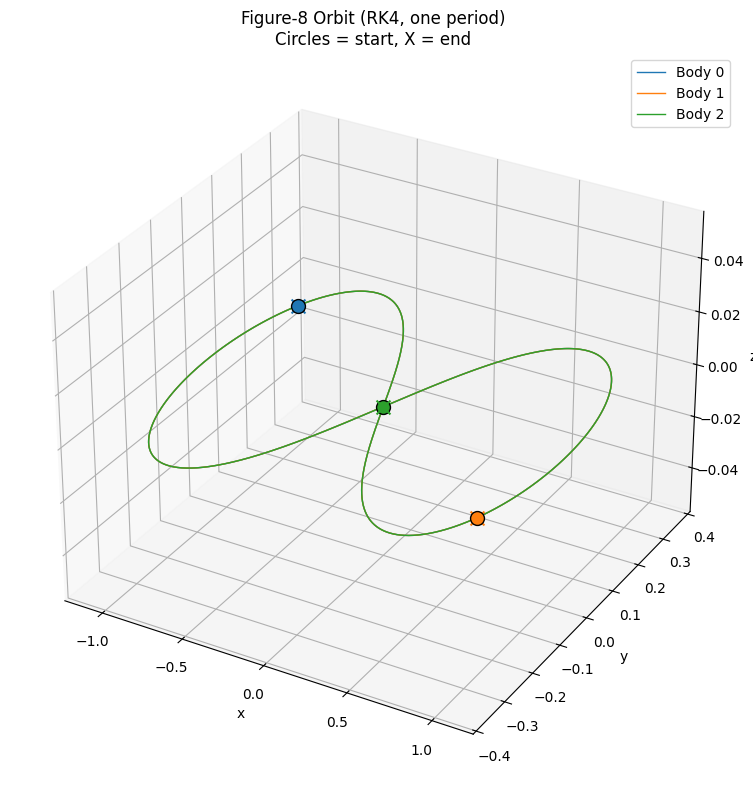


Return errors (final - initial position):
  Body 0: 5.467659e-05
  Body 1: 5.467143e-05
  Body 2: 1.093480e-04


In [27]:
# Run figure-8 with RK4 for one period
positions, velocities, masses, period = simulator.figure_8_initial_conditions()
initial_state = simulator.pack(positions, velocities)

dt = 0.001  # finer timestep than the circular test, since the orbit is more complex
t_span = (0.0, period)

times, states = simulator.integrate_rk4(initial_state, masses, t_span, dt)
print(f"Integrated {len(times) - 1} timesteps over {period:.4f} time units")

# Extract trajectories: states is shape (n_steps + 1, 18)
# Positions live in states[:, 0:9], reshape to (n_steps + 1, 3, 3) for clarity
n_outputs = states.shape[0]
trajectories = states[:, :9].reshape(n_outputs, 3, 3)
# trajectories[k, i, :] = position of body i at time k

# Plot in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    ax.plot(trajectories[:, i, 0],
            trajectories[:, i, 1],
            trajectories[:, i, 2],
            color=colors[i], label=f'Body {i}', linewidth=1)
    # Mark start and end positions
    ax.scatter(*trajectories[0, i],  color=colors[i], s=100, marker='o', edgecolors='black')
    ax.scatter(*trajectories[-1, i], color=colors[i], s=100, marker='x')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Figure-8 Orbit (RK4, one period)\nCircles = start, X = end')
ax.legend()
plt.tight_layout()
plt.show()

# How close does each body return to its starting position?
print("\nReturn errors (final - initial position):")
for i in range(3):
    error = np.linalg.norm(trajectories[-1, i] - trajectories[0, i])
    print(f"  Body {i}: {error:.6e}")

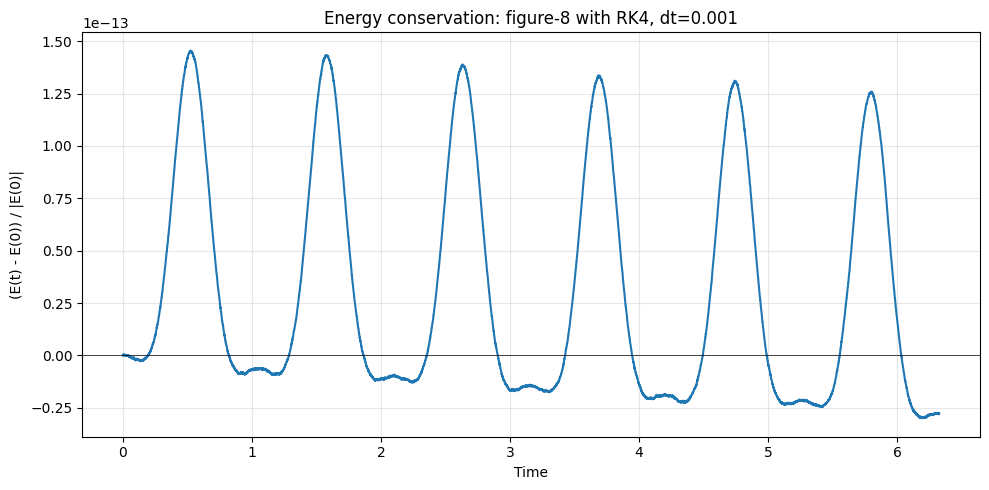

Initial energy: -1.2871419918
Final energy:   -1.2871419918
Max |relative error| during integration: 1.45e-13


In [28]:
# Compute energy at every timestep
n_outputs = states.shape[0]
energies = np.zeros(n_outputs)

for k in range(n_outputs):
    pos_k, vel_k = simulator.unpack(states[k])
    E, _, _ = simulator.compute_energy(pos_k, vel_k, masses)
    energies[k] = E

E_initial = energies[0]
relative_energy_error = (energies - E_initial) / abs(E_initial)

# Plot energy error vs time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times, relative_energy_error)
ax.set_xlabel('Time')
ax.set_ylabel('(E(t) - E(0)) / |E(0)|')
ax.set_title('Energy conservation: figure-8 with RK4, dt=0.001')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial energy: {E_initial:.10f}")
print(f"Final energy:   {energies[-1]:.10f}")
print(f"Max |relative error| during integration: {np.max(np.abs(relative_energy_error)):.2e}")

Integrated 6326 Verlet steps over 6.3259 time units


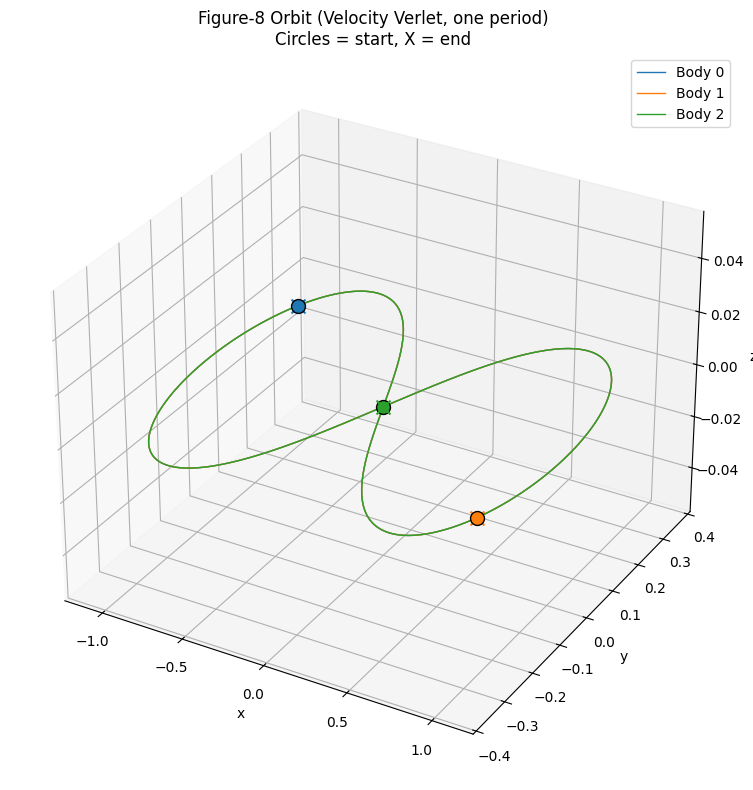


Return errors (final - initial position):
  Body 0: 5.360894e-05
  Body 1: 5.372791e-05
  Body 2: 1.073210e-04

Initial energy: -1.2871419918
Final energy:   -1.2871419918
Max |relative error|: 5.89e-07


In [29]:
# Test Verlet on figure-8, same setup as RK4 test yesterday
positions, velocities, masses, period = simulator.figure_8_initial_conditions()
initial_state = simulator.pack(positions, velocities)

dt = 0.001
t_span = (0.0, period)

times_v, states_v = simulator.integrate_verlet(initial_state, masses, t_span, dt)
print(f"Integrated {len(times_v) - 1} Verlet steps over {period:.4f} time units")

# Plot trajectories (3D)
n_outputs = states_v.shape[0]
trajectories_v = states_v[:, :9].reshape(n_outputs, 3, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    ax.plot(trajectories_v[:, i, 0],
            trajectories_v[:, i, 1],
            trajectories_v[:, i, 2],
            color=colors[i], label=f'Body {i}', linewidth=1)
    ax.scatter(*trajectories_v[0, i],  color=colors[i], s=100, marker='o', edgecolors='black')
    ax.scatter(*trajectories_v[-1, i], color=colors[i], s=100, marker='x')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Figure-8 Orbit (Velocity Verlet, one period)\nCircles = start, X = end')
ax.legend()
plt.tight_layout()
plt.show()

# Position return errors
print("\nReturn errors (final - initial position):")
for i in range(3):
    error = np.linalg.norm(trajectories_v[-1, i] - trajectories_v[0, i])
    print(f"  Body {i}: {error:.6e}")

# Energy conservation
energies_v = np.zeros(n_outputs)
for k in range(n_outputs):
    pos_k, vel_k = simulator.unpack(states_v[k])
    E, _, _ = simulator.compute_energy(pos_k, vel_k, masses)
    energies_v[k] = E

E_initial = energies_v[0]
relative_energy_error_v = (energies_v - E_initial) / abs(E_initial)
print(f"\nInitial energy: {E_initial:.10f}")
print(f"Final energy:   {energies_v[-1]:.10f}")
print(f"Max |relative error|: {np.max(np.abs(relative_energy_error_v)):.2e}")

Output points: 6327


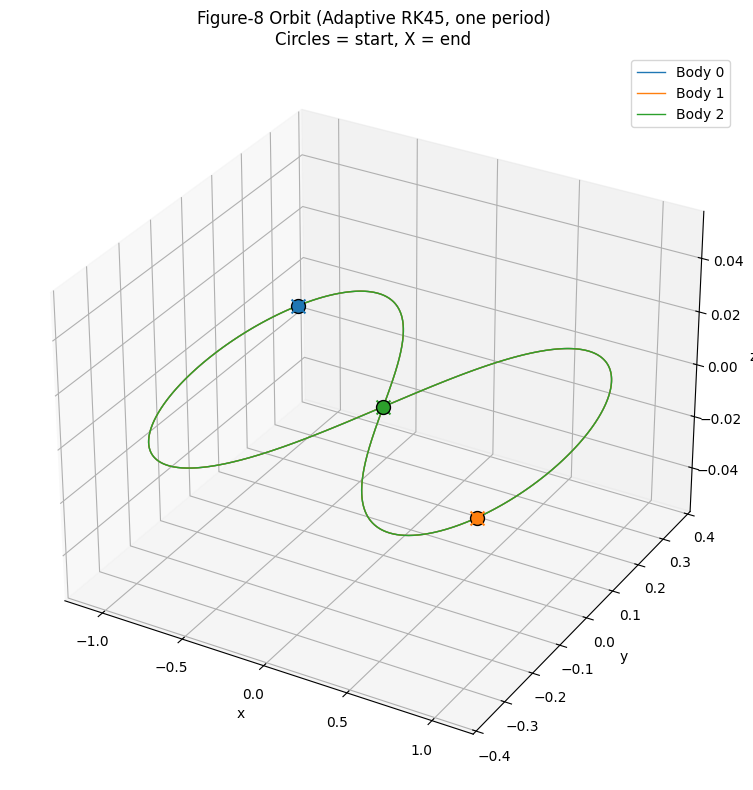


Return errors (final - initial position):
  Body 0: 9.177167e-08
  Body 1: 5.734811e-08
  Body 2: 1.488962e-07

Initial energy: -1.2871419918
Final energy:   -1.2871419645
Max |relative error|: 3.00e-08


In [30]:
# Test RK45 on figure-8
positions, velocities, masses, period = simulator.figure_8_initial_conditions()
initial_state = simulator.pack(positions, velocities)

t_span = (0.0, period)
dt_output = 0.001  # output density, NOT the integrator's stepsize

times_45, states_45 = simulator.integrate_rk45(
    initial_state, masses, t_span, dt_output=dt_output
)
print(f"Output points: {len(times_45)}")

# Plot trajectories
n_outputs = states_45.shape[0]
trajectories_45 = states_45[:, :9].reshape(n_outputs, 3, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(3):
    ax.plot(trajectories_45[:, i, 0],
            trajectories_45[:, i, 1],
            trajectories_45[:, i, 2],
            color=colors[i], label=f'Body {i}', linewidth=1)
    ax.scatter(*trajectories_45[0, i],  color=colors[i], s=100, marker='o', edgecolors='black')
    ax.scatter(*trajectories_45[-1, i], color=colors[i], s=100, marker='x')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Figure-8 Orbit (Adaptive RK45, one period)\nCircles = start, X = end')
ax.legend()
plt.tight_layout()
plt.show()

# Position return errors
print("\nReturn errors (final - initial position):")
for i in range(3):
    error = np.linalg.norm(trajectories_45[-1, i] - trajectories_45[0, i])
    print(f"  Body {i}: {error:.6e}")

# Energy conservation
energies_45 = np.zeros(n_outputs)
for k in range(n_outputs):
    pos_k, vel_k = simulator.unpack(states_45[k])
    E, _, _ = simulator.compute_energy(pos_k, vel_k, masses)
    energies_45[k] = E

E_initial = energies_45[0]
relative_energy_error_45 = (energies_45 - E_initial) / abs(E_initial)
print(f"\nInitial energy: {E_initial:.10f}")
print(f"Final energy:   {energies_45[-1]:.10f}")
print(f"Max |relative error|: {np.max(np.abs(relative_energy_error_45)):.2e}")

RK4 steps:    6326
Verlet steps: 6326
RK45 outputs: 6327 (adaptive internal steps)


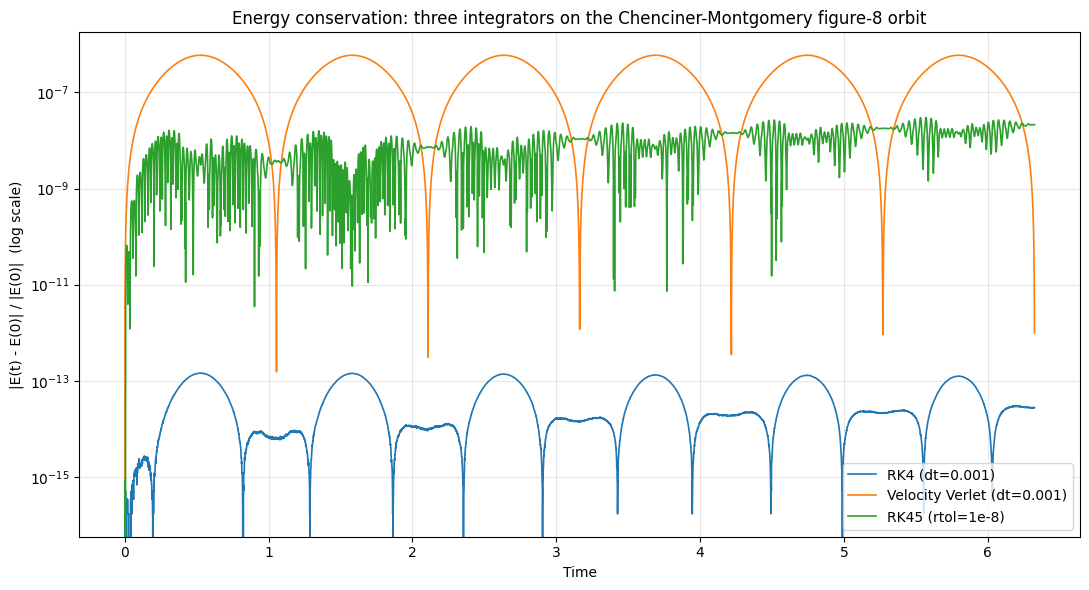


Max relative energy error over one period:
  RK4    : 1.45e-13
  Verlet : 5.89e-07
  RK45   : 3.00e-08


In [31]:
# === Three-integrator comparison on figure-8 ===
# Run all three integrators on identical initial conditions,
# compare energy error vs time.

positions, velocities, masses, period = simulator.figure_8_initial_conditions()
initial_state = simulator.pack(positions, velocities)
t_span = (0.0, period)
dt = 0.001  # fixed-step for RK4 and Verlet

# RK4
times_rk4, states_rk4 = simulator.integrate_rk4(initial_state, masses, t_span, dt)

# Verlet
times_v, states_v = simulator.integrate_verlet(initial_state, masses, t_span, dt)

# RK45 (adaptive; we set output spacing for plot resolution only)
times_45, states_45 = simulator.integrate_rk45(
    initial_state, masses, t_span, dt_output=dt
)

print(f"RK4 steps:    {len(times_rk4) - 1}")
print(f"Verlet steps: {len(times_v) - 1}")
print(f"RK45 outputs: {len(times_45)} (adaptive internal steps)")


def energy_error_curve(times, states, masses):
    """Compute relative energy error |E(t) - E(0)| / |E(0)| at every output."""
    n = states.shape[0]
    energies = np.zeros(n)
    for k in range(n):
        pos, vel = simulator.unpack(states[k])
        E, _, _ = simulator.compute_energy(pos, vel, masses)
        energies[k] = E
    return np.abs(energies - energies[0]) / np.abs(energies[0])


err_rk4 = energy_error_curve(times_rk4, states_rk4, masses)
err_v   = energy_error_curve(times_v,   states_v,   masses)
err_45  = energy_error_curve(times_45,  states_45,  masses)


# Plot: log-scale energy error vs time
fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogy(times_rk4, err_rk4, label='RK4 (dt=0.001)',           linewidth=1.2)
ax.semilogy(times_v,   err_v,   label='Velocity Verlet (dt=0.001)', linewidth=1.2)
ax.semilogy(times_45,  err_45,  label='RK45 (rtol=1e-8)',          linewidth=1.2)
ax.set_xlabel('Time')
ax.set_ylabel('|E(t) - E(0)| / |E(0)|  (log scale)')
ax.set_title('Energy conservation: three integrators on the Chenciner-Montgomery figure-8 orbit')
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


# Summary table
print("\nMax relative energy error over one period:")
print(f"  RK4    : {np.max(err_rk4):.2e}")
print(f"  Verlet : {np.max(err_v):.2e}")
print(f"  RK45   : {np.max(err_45):.2e}")

In [32]:
# Verify Pythagorean initial conditions
positions, velocities, masses = simulator.pythagorean_initial_conditions()

print("Positions:")
print(positions)
print(f"\nMasses: {masses}")

# Pairwise distances should be 3, 4, 5
for i in range(3):
    for j in range(i + 1, 3):
        d = np.linalg.norm(positions[j] - positions[i])
        print(f"Distance |r_{i} - r_{j}| = {d:.4f}")

# Center of mass should be at origin
com = np.sum(masses[:, None] * positions, axis=0) / np.sum(masses)
print(f"\nCenter of mass: {com}  (should be ~zero)")

# Total momentum should be zero (bodies at rest)
total_mom = np.sum(masses[:, None] * velocities, axis=0)
print(f"Total momentum: {total_mom}")

Positions:
[[ 1.  3.  0.]
 [-2. -1.  0.]
 [ 1. -1.  0.]]

Masses: [3. 4. 5.]
Distance |r_0 - r_1| = 5.0000
Distance |r_0 - r_2| = 4.0000
Distance |r_1 - r_2| = 3.0000

Center of mass: [0. 0. 0.]  (should be ~zero)
Total momentum: [0. 0. 0.]


In [33]:
# === Pythagorean problem: three integrators, no softening, no collisions ===

positions, velocities, masses = simulator.pythagorean_initial_conditions()
initial_state = simulator.pack(positions, velocities)

# Integrate to t = 70 — far enough to see the famous ejection (Szebehely-Peters 1967)
t_span = (0.0, 70.0)
dt_fixed = 0.001   # for RK4 and Verlet

print("Running RK4...")
times_rk4, states_rk4 = simulator.integrate_rk4(initial_state, masses, t_span, dt_fixed)
print(f"  Completed {len(times_rk4) - 1} steps")

print("Running Velocity Verlet...")
times_v, states_v = simulator.integrate_verlet(initial_state, masses, t_span, dt_fixed)
print(f"  Completed {len(times_v) - 1} steps")

print("Running RK45...")
times_45, states_45 = simulator.integrate_rk45(initial_state, masses, t_span, dt_output=dt_fixed)
print(f"  Output points: {len(times_45)}")

Running RK4...
  Completed 70000 steps
Running Velocity Verlet...
  Completed 70000 steps
Running RK45...
  Output points: 70001


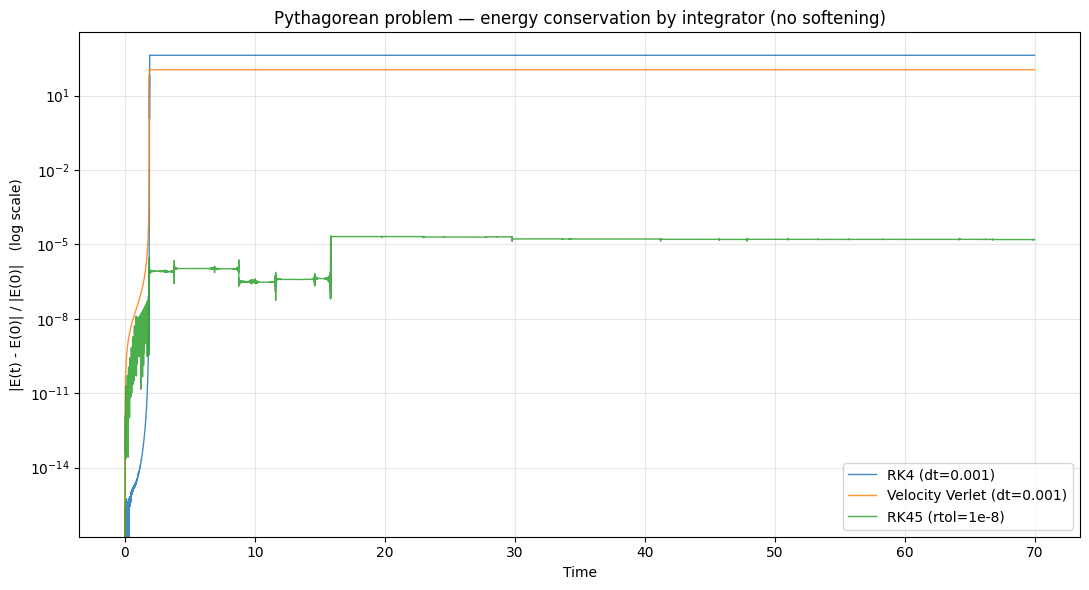


Initial energy: -12.816667
RK4   final energy: 5355.930720    max rel error: 4.19e+02
Verlet final energy: 1388.957207    max rel error: 1.18e+02
RK45  final energy: -12.816466    max rel error: 2.13e-05


In [34]:
# === Diagnostic: energy error vs time for all three integrators ===

def energy_error_curve(states, masses):
    n = states.shape[0]
    energies = np.zeros(n)
    for k in range(n):
        pos, vel = simulator.unpack(states[k])
        E, _, _ = simulator.compute_energy(pos, vel, masses)
        energies[k] = E
    E0 = energies[0]
    return energies, np.abs(energies - E0) / np.abs(E0)

E_rk4, err_rk4 = energy_error_curve(states_rk4, masses)
E_v,   err_v   = energy_error_curve(states_v,   masses)
E_45,  err_45  = energy_error_curve(states_45,  masses)

fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogy(times_rk4, err_rk4, label='RK4 (dt=0.001)',           linewidth=1.0, alpha=0.85)
ax.semilogy(times_v,   err_v,   label='Velocity Verlet (dt=0.001)', linewidth=1.0, alpha=0.85)
ax.semilogy(times_45,  err_45,  label='RK45 (rtol=1e-8)',          linewidth=1.0, alpha=0.85)
ax.set_xlabel('Time')
ax.set_ylabel('|E(t) - E(0)| / |E(0)|   (log scale)')
ax.set_title('Pythagorean problem — energy conservation by integrator (no softening)')
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Print initial and final energies
print(f"\nInitial energy: {E_rk4[0]:.6f}")
print(f"RK4   final energy: {E_rk4[-1]:.6f}    max rel error: {np.max(err_rk4):.2e}")
print(f"Verlet final energy: {E_v[-1]:.6f}    max rel error: {np.max(err_v):.2e}")
print(f"RK45  final energy: {E_45[-1]:.6f}    max rel error: {np.max(err_45):.2e}")

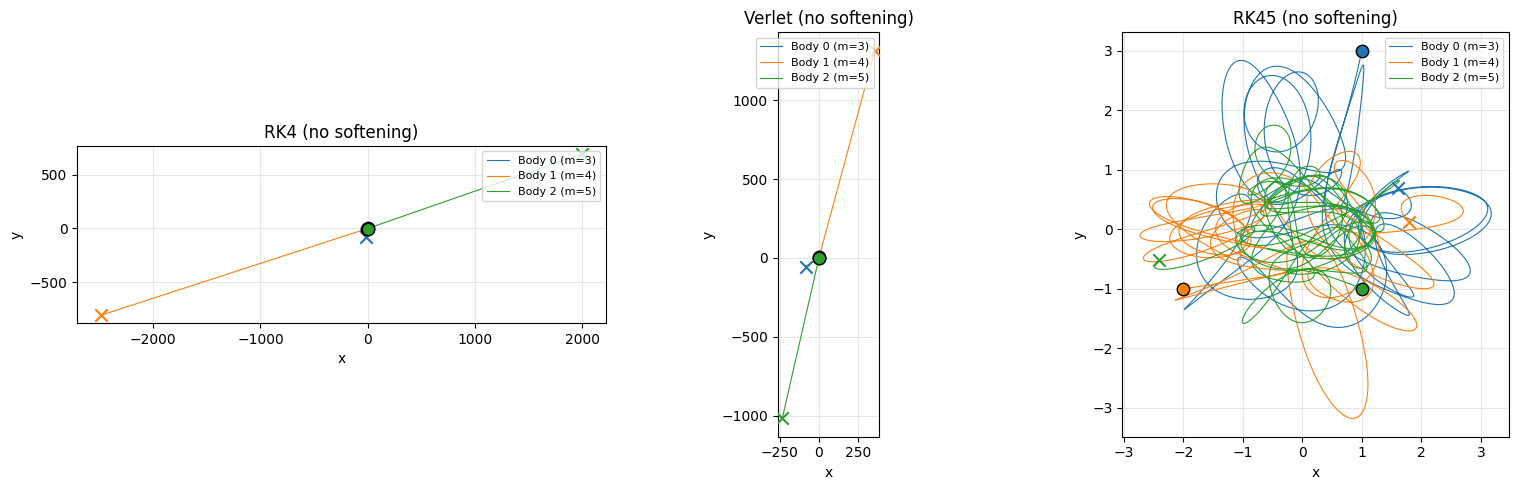

In [35]:
# === Trajectories: what did each integrator actually compute? ===

def extract_trajectories(states):
    n = states.shape[0]
    return states[:, :9].reshape(n, 3, 3)

traj_rk4 = extract_trajectories(states_rk4)
traj_v   = extract_trajectories(states_v)
traj_45  = extract_trajectories(states_45)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']
labels = ['Body 0 (m=3)', 'Body 1 (m=4)', 'Body 2 (m=5)']

for ax, traj, title in zip(axes,
                            [traj_rk4, traj_v, traj_45],
                            ['RK4 (no softening)', 'Verlet (no softening)', 'RK45 (no softening)']):
    for i in range(3):
        ax.plot(traj[:, i, 0], traj[:, i, 1], color=colors[i], label=labels[i], linewidth=0.8)
        ax.scatter(*traj[0, i, :2],  color=colors[i], s=80, marker='o', edgecolors='black', zorder=5)
        ax.scatter(*traj[-1, i, :2], color=colors[i], s=80, marker='x', zorder=5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
fig.savefig('pythagorean_trajectories_no_softening.png', dpi=150, bbox_inches='tight')

Diagnostics from ground-truth trajectory:
  Minimum pairwise distance: 0.0067
  Mean pairwise distance:    1.6190
  Median pairwise distance:  1.6113
  Close approaches below 0.1:  153
  Close approaches below 0.01: 2

Recommended softening: ε = 0.6682
  (1.5× the 5th percentile of pairwise distances)

Re-running Pythagorean with softening ε = 0.6682


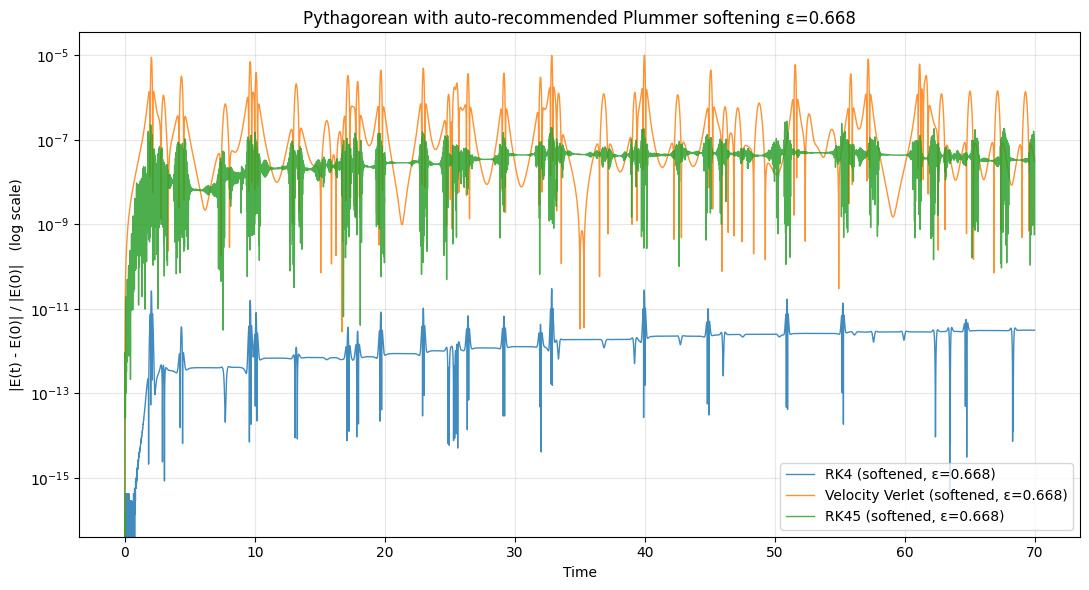


Initial energy (softened): -12.584837
RK4    max rel error: 3.01e-11
Verlet max rel error: 1.01e-05
RK45   max rel error: 2.77e-07


In [44]:
# === Pythagorean with auto-recommended softening ===

# Helper function: relative energy error curve, using softened potential
def softened_energy_error_curve(states, masses, softening):
    n = states.shape[0]
    energies = np.zeros(n)
    for k in range(n):
        pos, vel = simulator.unpack(states[k])
        E, _, _ = simulator.compute_energy(pos, vel, masses, softening=softening)
        energies[k] = E
    E0 = energies[0]
    return energies, np.abs(energies - E0) / np.abs(E0)

# Step 1: compute recommended softening from RK45 ground truth
eps_auto, diag = simulator.recommend_softening(states_45,
                                                percentile_above=5.0,
                                                safety_factor=1.5)

print(f"Diagnostics from ground-truth trajectory:")
print(f"  Minimum pairwise distance: {diag['min_distance']:.4f}")
print(f"  Mean pairwise distance:    {diag['mean_distance']:.4f}")
print(f"  Median pairwise distance:  {diag['median_distance']:.4f}")
print(f"  Close approaches below 0.1:  {diag['n_below_0.1']}")
print(f"  Close approaches below 0.01: {diag['n_below_0.01']}")
print(f"\nRecommended softening: ε = {eps_auto:.4f}")
print(f"  ({diag['safety_factor']}× the 5th percentile of pairwise distances)")

# Step 2: re-run all three integrators with the auto-computed softening
print(f"\nRe-running Pythagorean with softening ε = {eps_auto:.4f}")
times_rk4b, states_rk4b = simulator.integrate_rk4(
    initial_state, masses, t_span, dt_fixed, softening=eps_auto)
times_vb, states_vb = simulator.integrate_verlet(
    initial_state, masses, t_span, dt_fixed, softening=eps_auto)
times_45b, states_45b = simulator.integrate_rk45(
    initial_state, masses, t_span, dt_output=dt_fixed, softening=eps_auto)

# Step 3: energy diagnostics
E_rk4b, err_rk4b = softened_energy_error_curve(states_rk4b, masses, eps_auto)
E_vb,   err_vb   = softened_energy_error_curve(states_vb,   masses, eps_auto)
E_45b,  err_45b  = softened_energy_error_curve(states_45b,  masses, eps_auto)

# Step 4: plot
fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogy(times_rk4b, err_rk4b, label=f'RK4 (softened, ε={eps_auto:.3f})',           linewidth=1.0, alpha=0.85)
ax.semilogy(times_vb,   err_vb,   label=f'Velocity Verlet (softened, ε={eps_auto:.3f})', linewidth=1.0, alpha=0.85)
ax.semilogy(times_45b,  err_45b,  label=f'RK45 (softened, ε={eps_auto:.3f})',          linewidth=1.0, alpha=0.85)
ax.set_xlabel('Time')
ax.set_ylabel('|E(t) - E(0)| / |E(0)|   (log scale)')
ax.set_title(f'Pythagorean with auto-recommended Plummer softening ε={eps_auto:.3f}')
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()
fig.savefig('pythagorean_softened_auto_energy.png', dpi=150, bbox_inches='tight')

# Step 5: numerical summary
print(f"\nInitial energy (softened): {E_rk4b[0]:.6f}")
print(f"RK4    max rel error: {np.max(err_rk4b):.2e}")
print(f"Verlet max rel error: {np.max(err_vb):.2e}")
print(f"RK45   max rel error: {np.max(err_45b):.2e}")

In [40]:
# === Pythagorean with collisions enabled ===
# Bodies are point-like-but-not-quite (radius 0.05). Collisions trigger when
# any two come within radius_i + radius_j of each other.
# Softening is computed automatically from the un-softened RK45 ground truth.

positions, velocities, masses_init = simulator.pythagorean_initial_conditions()
initial_state = simulator.pack(positions, velocities)
radii_init = np.array([0.05, 0.05, 0.05])
t_span = (0.0, 70.0)
dt_fixed = 0.001

# Use the auto-softening function based on close approaches in RK45 ground truth
eps_collision, soft_diag = simulator.recommend_softening(states_45,
                                                         percentile_above=5.0,
                                                         safety_factor=1.5)
print(f"Auto-recommended softening: ε = {eps_collision:.4f}")
print(f"  Based on 5th percentile of pairwise distances: {soft_diag['p5.0_distance']:.4f}")
print(f"  Safety factor: {soft_diag['safety_factor']}x")

print(f"\nRunning RK4 with collisions (radius {radii_init[0]}, softening ε={eps_collision:.4f})...")
times_c, states_c, masses_hist, radii_hist, events = simulator.integrate_with_collisions(
    initial_state, masses_init, radii_init, t_span, dt_fixed,
    integrator="rk4", softening=eps_collision
)
print(f"  Completed {len(times_c) - 1} steps")
print(f"  Collision events: {len(events)}")
for k, ev in enumerate(events):
    print(f"    Event {k+1}: t = {ev['time']:.3f}, bodies {ev['merged']} merged "
          f"into slot {ev['kept']}, KE lost = {ev['ke_lost']:.4f}")

print(f"\nFinal masses: {masses_hist[-1]}")
print(f"Final radii: {radii_hist[-1]}")

Auto-recommended softening: ε = 0.6682
  Based on 5th percentile of pairwise distances: 0.4454
  Safety factor: 1.5x

Running RK4 with collisions (radius 0.05, softening ε=0.6682)...
  Completed 70000 steps
  Collision events: 2
    Event 1: t = 2.037, bodies (1, 2) merged into slot 2, KE lost = 23.4625
    Event 2: t = 3.013, bodies (0, 2) merged into slot 2, KE lost = 33.4229

Final masses: [ 0.  0. 12.]
Final radii: [0.         0.         0.07211248]


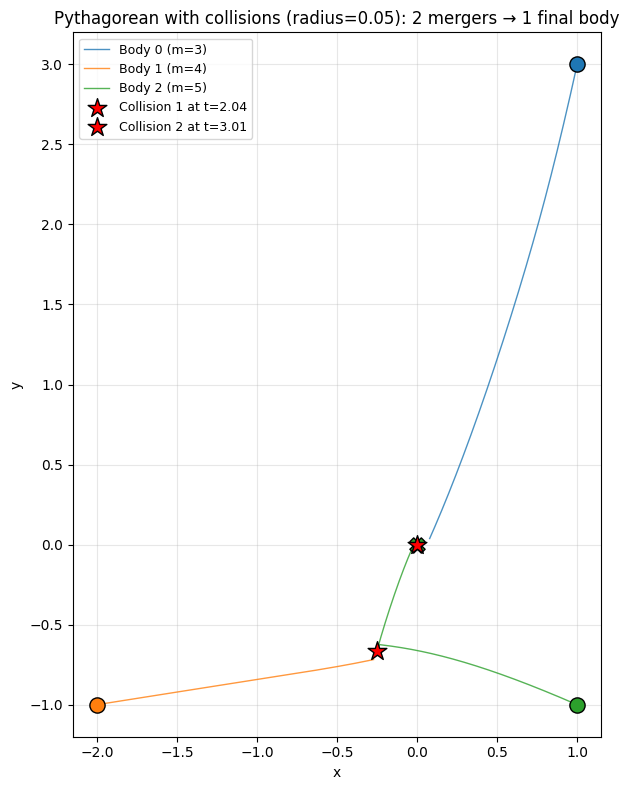

In [41]:
# === Visualize the collision trajectory ===

# Extract positions; for the ghost bodies (mass = 0), skip them in plotting
n = states_c.shape[0]
traj_c = states_c[:, :9].reshape(n, 3, 3)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['tab:blue', 'tab:orange', 'tab:green']
labels = ['Body 0 (m=3)', 'Body 1 (m=4)', 'Body 2 (m=5)']

for i in range(3):
    # Only plot timesteps where this body is active (mass > 0)
    active = masses_hist[:, i] > 0
    ax.plot(traj_c[active, i, 0], traj_c[active, i, 1],
            color=colors[i], label=labels[i], linewidth=1.0, alpha=0.8)

# Mark collision events on the plot
for k, ev in enumerate(events):
    # Find the timestep index of this event
    t_event = ev['time']
    idx = np.argmin(np.abs(times_c - t_event))
    pos = traj_c[idx, ev['kept']]
    ax.scatter(pos[0], pos[1], s=200, marker='*', color='red',
                edgecolors='black', zorder=10,
                label=f'Collision {k+1} at t={t_event:.2f}' if k < 2 else None)

# Mark final positions (only active bodies)
final_masses = masses_hist[-1]
for i in range(3):
    if final_masses[i] > 0:
        ax.scatter(*traj_c[-1, i, :2], color=colors[i], s=120, marker='X',
                    edgecolors='black', zorder=8)

# Mark starting positions
for i in range(3):
    ax.scatter(*traj_c[0, i, :2], color=colors[i], s=120, marker='o',
                edgecolors='black', zorder=8)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_title(f'Pythagorean with collisions (radius=0.05): {len(events)} mergers → 1 final body')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig.savefig('pythagorean_with_collisions.png', dpi=150, bbox_inches='tight')